# Time-Resolved Decoding

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
REPO_ROOT = next(path for path in (cwd, *cwd.parents) if (path / 'scripts' / 'config.py').exists())
SCRIPTS_DIR = REPO_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import config
EPOCHS_ROOT = REPO_ROOT / 'output_mne' / 'epochs'

from decoding.decoding_utils.plotting import plot_time_resolved_decoding_summary
from decoding.decoding_utils.time_resolved_decoding_utils import run_group_decoding
from decoding.decoding_utils.epoch_io import get_epochs_path

In [2]:
PIPELINE = 'proposed'
CONTEXTS = ['mid_high', 'high_high']
WINDOW_START = 0.24
WINDOW_END = 0.34
SUBJECTS = sorted(config.SUBJECT_INFO)

subjects_to_run = [
    sid for sid in SUBJECTS
    if get_epochs_path(sid, PIPELINE, 'feedback', root_dir=EPOCHS_ROOT).exists()
]
if not subjects_to_run:
    raise FileNotFoundError('No saved feedback epochs found. Run make_feedback_epochs.ipynb first.')

summary_df, _, timecourse_store = run_group_decoding(
    subjects_to_run,
    PIPELINE,
    CONTEXTS,
    window_start=WINDOW_START,
    window_end=WINDOW_END,
    root_dir=EPOCHS_ROOT,
)
summary_df

,subject_id,context,n_trials,n_win,n_loss,cv_splits,window_start_sec,window_end_sec,window_auc_mean,peak_auc,peak_time_sec
0,27,mid_high,67,42,25,5,0.24,0.34,0.580128,0.753333,-0.168
1,27,high_high,133,77,56,5,0.24,0.34,0.519919,0.685884,0.156
2,28,mid_high,53,45,8,5,0.24,0.34,0.664103,0.911111,-0.028
3,28,high_high,32,27,5,5,0.24,0.34,0.678974,0.960000,0.032
4,29,mid_high,56,27,29,5,0.24,0.34,0.426282,0.710000,0.052
5,29,high_high,106,52,54,5,0.24,0.34,0.495238,0.670909,0.500
6,30,mid_high,62,40,22,5,0.24,0.34,0.403510,0.687500,-0.168
7,30,high_high,123,61,62,5,0.24,0.34,0.600999,0.663034,0.260
8,31,mid_high,64,41,23,5,0.24,0.34,0.616907,0.906250,0.156
9,31,high_high,131,95,36,5,0.24,0.34,0.606051,0.864098,0.100


['mid_high', 'high_high']

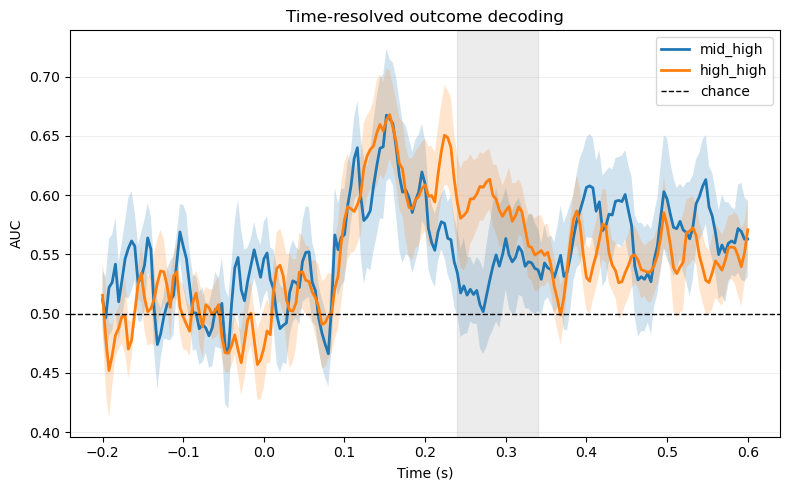

In [3]:
fig, ax, plotted_contexts = plot_time_resolved_decoding_summary(
    timecourse_store,
    subjects_to_run,
    CONTEXTS,
    WINDOW_START,
    WINDOW_END,
)
plotted_contexts
